In [1]:
import pandas as pd

In [29]:
file_path = "dataset.txt"

lines = []
with open(file_path, "r", encoding="utf-8") as f:
    line = []
    counter = -1
    for i, line in enumerate(f):
        if (i) % 8 == 0:
            lines.append([])
            counter += 1
        else:
            if line != "\n":
                lines[counter].append(line[line.find(":")+2:-1])
#         if i == 15:
#             break


df = pd.DataFrame(lines,
                  columns=["TEXT", "STAGE", "STRANGE", "GROUP", "EMOTION", "TRIGGER"])



In [30]:
df.head()

,TEXT,STAGE,STRANGE,GROUP,EMOTION,TRIGGER
0,"Слушай, я не хочу опять начинать, но ты снова ...",Предконфликтная,Низкая,Гнев,Раздражение,Быт
1,"Да замолчи ты уже, ради бога, ты слышишь тольк...",Пик,Высокая,Гнев,Злость,Личность
2,"Я видела твой телефон, когда пришло уведомлени...",Инцидент,Средняя,Страх,Напряжение/Нервозность,Ревность
3,"Прости, что я так сорвалась вчера, я действите...",Разрешение,Средняя,Социальные,Раскаяние,Внимание
4,"Опять твоя мама звонит в семь утра, чтобы расс...",Эскалация,Средняя,Гнев,Неодобрение,Родня


In [37]:
df.describe()

,TEXT,STAGE,STRANGE,GROUP,EMOTION,TRIGGER
count,4000,4000,4000,4000,4000,4000
unique,3299,5,3,7,23,11
top,"Я просто хочу, чтобы меня никто не трогал хотя...",Инцидент,Средняя,Гнев,Раздражение,Личность
freq,7,933,1740,1947,773,785


In [39]:
df = df.drop_duplicates(subset=["TEXT"])

In [41]:
df.describe()

,TEXT,STAGE,STRANGE,GROUP,EMOTION,TRIGGER
count,3299,3299,3299,3299,3299,3299
unique,3299,5,3,7,23,11
top,Почему я должна постоянно оправдываться за каж...,Инцидент,Средняя,Гнев,Раздражение,Личность
freq,1,764,1461,1605,632,637


In [42]:
df.head(10)

,TEXT,STAGE,STRANGE,GROUP,EMOTION,TRIGGER
0,"Слушай, я не хочу опять начинать, но ты снова ...",Предконфликтная,Низкая,Гнев,Раздражение,Быт
1,"Да замолчи ты уже, ради бога, ты слышишь тольк...",Пик,Высокая,Гнев,Злость,Личность
2,"Я видела твой телефон, когда пришло уведомлени...",Инцидент,Средняя,Страх,Напряжение/Нервозность,Ревность
3,"Прости, что я так сорвалась вчера, я действите...",Разрешение,Средняя,Социальные,Раскаяние,Внимание
4,"Опять твоя мама звонит в семь утра, чтобы расс...",Эскалация,Средняя,Гнев,Неодобрение,Родня
5,"Нам не обязательно сейчас это решать, давай пр...",Предконфликтная,Низкая,Нейтральные,Нейтральность,Контроль
6,"Боже, я так рада, что мы наконец-то решили это...",Разрешение,Высокая,Позитив,Облегчение,Деньги
7,Ты опять потратил все деньги на свои дурацкие ...,Эскалация,Высокая,Гнев,Злость,Деньги
8,Я просто смотрю на тебя и не узнаю того челове...,Инцидент,Средняя,Грусть,Горе/Грусть,Внимание
9,"Ты сегодня был таким классным с детьми, я виде...",Разрешение,Средняя,Социальные,Признательность/Радость,Дети


In [49]:
df.iloc[0]["TEXT"].split()[0]

'Слушай,'

In [53]:
df[df["TEXT"].apply(lambda x: x.split(",")[1 if len(x.split(",")) > 1 else 0] == " я был неправ")]["TEXT"]

104     Слушай, я был неправ, когда сказал, что твоё х...
217     Слушай, я был неправ, когда сказал, что ты пло...
804     Слушай, я был неправ, когда накричал на тебя и...
1184    Слушай, я был неправ, когда накричал на тебя в...
Name: TEXT, dtype: object

In [58]:
df.loc[804]["TEXT"]

'Слушай, я был неправ, когда накричал на тебя из-за той разбитой вазы. Давай просто забудем об этом и закажем сегодня пиццу.'

In [60]:
df.loc[1184]["TEXT"]

'Слушай, я был неправ, когда накричал на тебя вчера из-за той разбитой тарелки. Давай просто забудем об этом и закажем сегодня твою любимую пиццу.'

In [61]:
!pip install rapidfuzz

     ---------------------------------------- 1.8/1.8 MB 1.3 MB/s eta 0:00:00


In [62]:
from rapidfuzz import fuzz

def mark_similar_texts(texts, threshold=85):  # 85% схожести — подстрой под свои данные
    """
    Отмечает дубликаты: оставляет только первое вхождение похожих текстов.
    """
    n = len(texts)
    marked = [True] * n  # True — оставить
    
    for i in range(n):
        if not marked[i]:  # уже помечен на удаление
            continue
        for j in range(i + 1, n):
            if marked[j] and fuzz.ratio(texts[i], texts[j]) >= threshold:
                marked[j] = False  # пометить на удаление
    
    return marked

In [64]:
uniq_df = df[mark_similar_texts(df["TEXT"].tolist())].copy()

In [95]:
uniq_df.to_csv("uniq_data.csv", index=False, encoding="utf-8")

In [73]:
uniq_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1660 entries, 0 to 3900
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   TEXT     1660 non-null   object
 1   STAGE    1660 non-null   object
 2   STRANGE  1660 non-null   object
 3   GROUP    1660 non-null   object
 4   EMOTION  1660 non-null   object
 5   TRIGGER  1660 non-null   object
dtypes: object(6)
memory usage: 90.8+ KB


<AxesSubplot:>

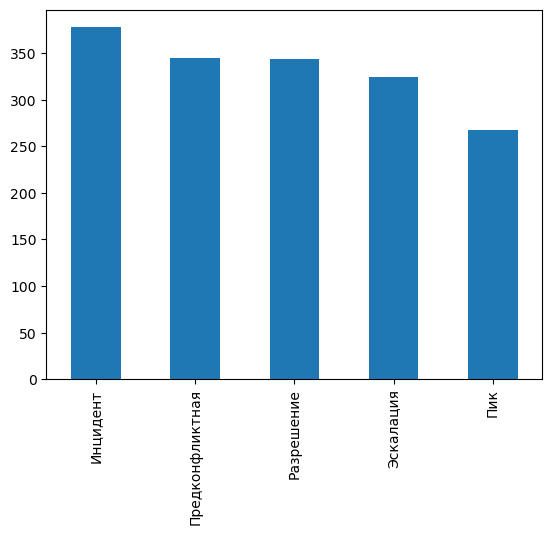

In [78]:
uniq_df["STAGE"].value_counts().plot(kind="bar")

<AxesSubplot:>

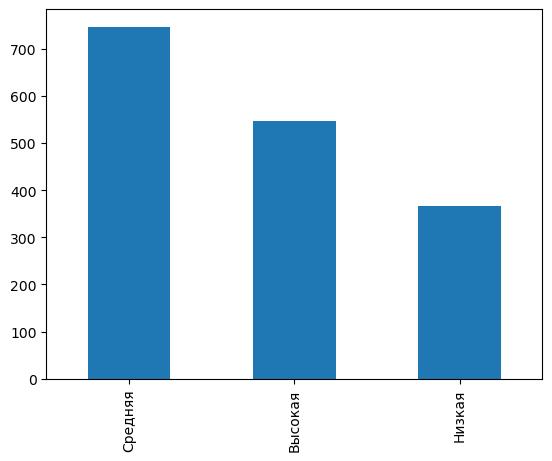

In [74]:
uniq_df["STRANGE"].value_counts().plot(kind="bar")

<AxesSubplot:>

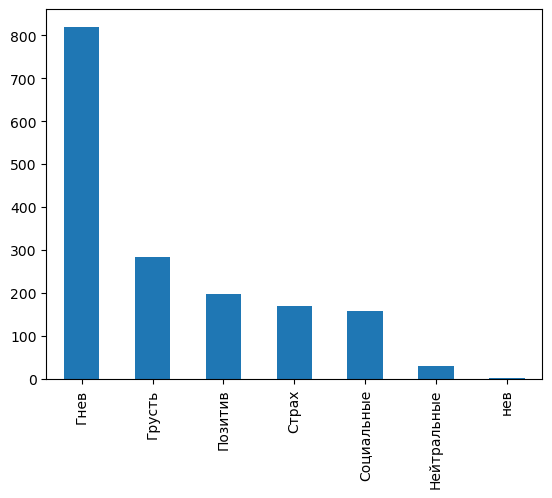

In [79]:
uniq_df["GROUP"].value_counts().plot(kind="bar")

<AxesSubplot:>

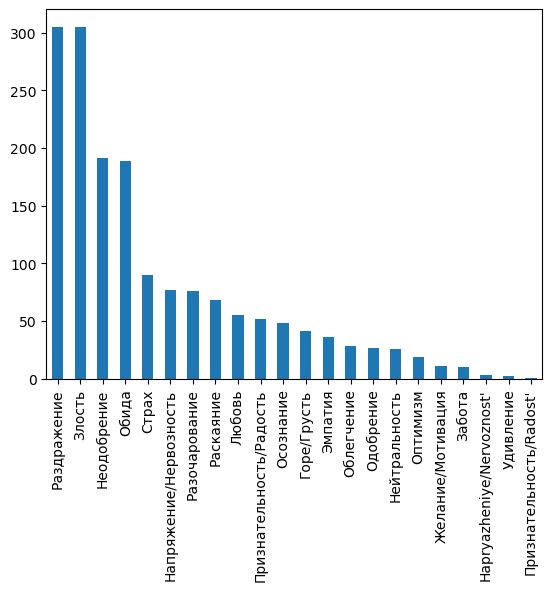

In [80]:
uniq_df["EMOTION"].value_counts().plot(kind="bar")

<AxesSubplot:>

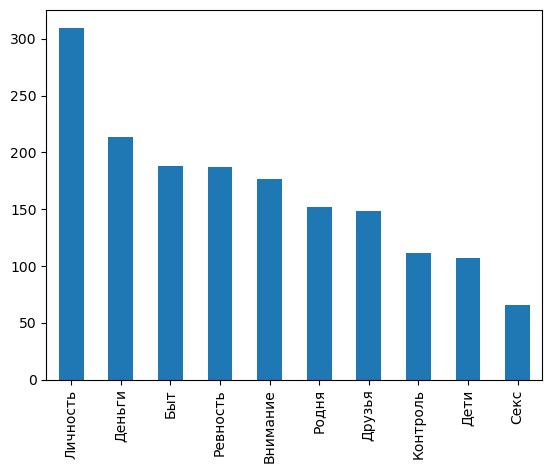

In [81]:
uniq_df["TRIGGER"].value_counts().plot(kind="bar")

In [84]:
uniq_df.loc[1392, "GROUP"] = "Гнев"

In [86]:
import numpy as np

In [91]:
uniq_df["EMOTION"] = np.where(uniq_df["EMOTION"] == "Признательность/Radost'", "Признательность/Радость", uniq_df["EMOTION"])

<AxesSubplot:>

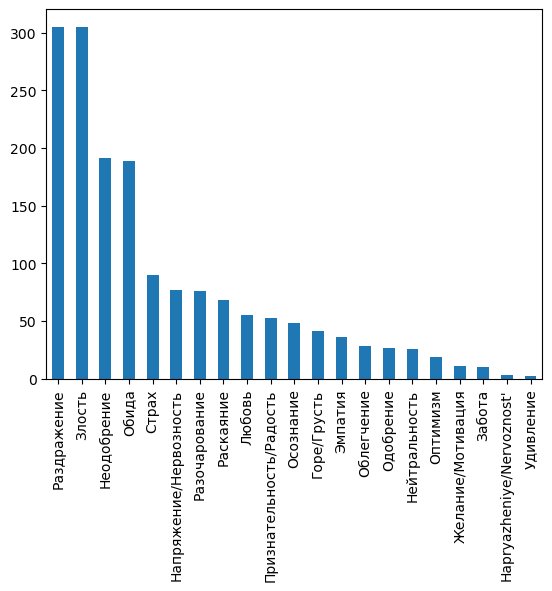

In [92]:
uniq_df["EMOTION"].value_counts().plot(kind="bar")

In [93]:
uniq_df["EMOTION"] = np.where(uniq_df["EMOTION"] == "Наpryazheniye/Nervoznost'", "Напряжение/Нервозность", uniq_df["EMOTION"])

<AxesSubplot:>

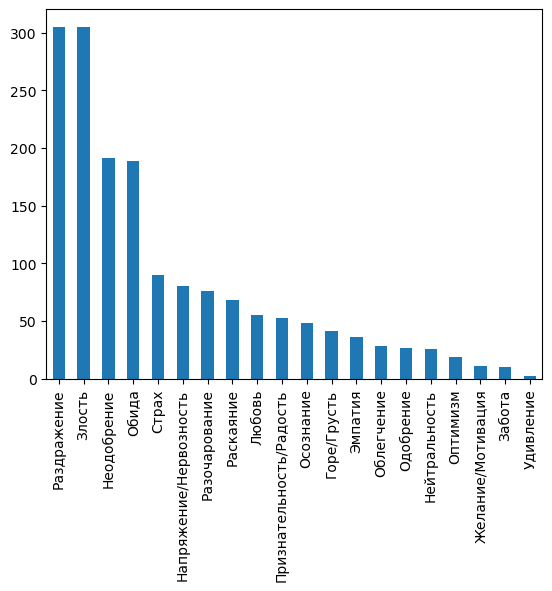

In [94]:
uniq_df["EMOTION"].value_counts().plot(kind="bar")